# 01 — Build the global 0.5° grid

Creates the base `(lat, lon)` grid used by every variable notebook and stores a Natural Earth land mask so downstream notebooks can skip ocean cells.

In [ ]:
%pip install netCDF4
%pip install regionmask
%pip install xarray

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.8/22.8 MB 1.2 MB/s  0:00:18m0:00:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [netCDF4]m1/2 [netCDF4]
Note: you may need to restart the kernel to use updated packages.


In [1]:
import numpy as np
import xarray as xr
import regionmask

from helpers import PROCESSED_DIR

## Mesh

Cell centers at 0.5° spacing: 720 lon × 360 lat = 259 200 cells globally.

In [2]:
RES = 0.5
lon = np.arange(-180 + RES / 2, 180, RES)
lat = np.arange(-90 + RES / 2, 90, RES)
print(f'{lon.size} lon × {lat.size} lat = {lon.size * lat.size:,} cells')

720 lon × 360 lat = 259,200 cells


## Land mask

Natural Earth 110m land polygons via `regionmask`. Result is `1` for land cells, `0` for ocean.

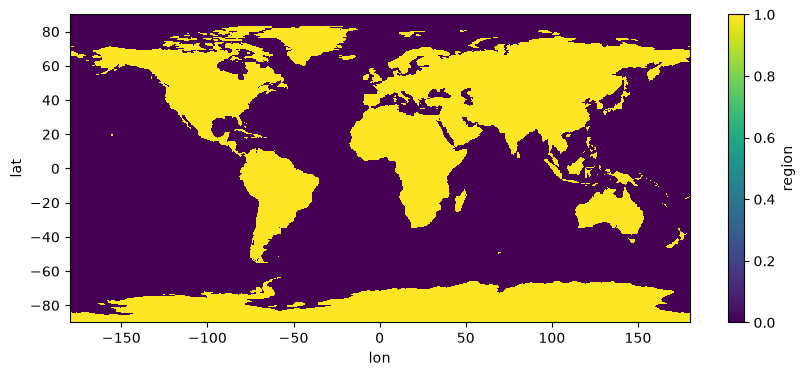

In [3]:
land = regionmask.defined_regions.natural_earth_v5_0_0.land_110
mask = land.mask(lon, lat)  # 0 where land, NaN elsewhere
is_land = (~mask.isnull()).astype('int8')
is_land.plot(figsize=(10, 4))

## Save

In [4]:
grid = xr.Dataset(
    {'is_land': is_land},
    attrs={'resolution_deg': RES, 'source': 'Natural Earth 110m via regionmask'},
)

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
out = PROCESSED_DIR / 'grid.nc'
grid.to_netcdf(out)
print(f'wrote {out}')

ValueError: cannot write NetCDF files because none of the suitable backend libraries (netCDF4, h5netcdf, scipy) are installed